# Network Intrusion Detection - Unified MLP Experiments

8개 네트워크 침입탐지 데이터셋(NSL-KDD, UNSW-NB15, CICIDS2017/2018, CIC-DDoS2019, Bot-IoT, TON_IoT, RT-IoT2022)에서 6종 손실함수(ce, pwce, lwce, plwce, cb, focal)를 비교한다.

- tabular/CIFAR 실험과 동일한 6 losses, Optuna 범위(PWCE 0.3-5.0, PLWCE 0.5-6.0, Focal 1.0-5.0), 5 seeds
- 데이터 로딩은 `network_data/scr/data_handler.py`의 `load_network_dataset(name)` 사용
- 데이터셋별로 load -> Optuna -> 학습 -> 저장 -> 메모리 해제 (대용량 대응)


In [1]:
# Cell 0: Setup
!pip install -q optuna openpyxl kagglehub

import os, sys, gc, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import optuna
from optuna.samplers import GridSampler

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    print('Google Drive mounted')
except Exception:
    IN_COLAB = False
    print('Local environment')

if IN_COLAB:
    REPO_PATH = '/content/drive/MyDrive/imbalanced-data-LWCE'
else:
    REPO_PATH = 'C:/Users/Seung/Desktop/Research/Deep_Learning/imbalanced-data-LWCE'

RESULTS_DIR = f'{REPO_PATH}/network_data/results/mlp'
os.makedirs(RESULTS_DIR, exist_ok=True)

SCR_PATH     = f'{REPO_PATH}/network_data/scr'
IMG_CLF_PATH = f'{REPO_PATH}/image_classification'
for p in [SCR_PATH, IMG_CLF_PATH]:
    if p not in sys.path:
        sys.path.insert(0, p)

try:
    from data_handler import load_network_dataset, DATASETS
    from custom_losses import get_clf_loss
    print('Modules loaded')
except ModuleNotFoundError as e:
    print(f'Module load failed: {e}')
    raise

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'  GPU: {torch.cuda.get_device_name(0)}')

# --- Constants (tabular/CIFAR와 통일) ---
LOSS_CONFIGS = ['ce', 'pwce', 'sqce', 'lwce', 'plwce', 'cb', 'focal']   # 7 losses (WCE 제외, sqce=sqrt-CE)
SEEDS        = [42, 43, 44, 45, 46]

BATCH_SIZE   = 512
FINAL_EPOCHS = 50
PROXY_EPOCHS = 10
PROXY_RATIO  = 0.20
N_PWCE  = 30   # alpha  linspace(0.3, 5.0)
N_PLWCE = 30   # alpha  linspace(0.5, 6.0)
N_FOCAL = 30   # gamma  linspace(1.0, 5.0)

print(f'\nDatasets: {DATASETS}')
print(f'Total: {len(DATASETS)} x {len(LOSS_CONFIGS)} losses x {len(SEEDS)} seeds = '
      f'{len(DATASETS)*len(LOSS_CONFIGS)*len(SEEDS)} runs')


Mounted at /content/drive
Google Drive mounted
Modules loaded
Device: cuda
  GPU: Tesla T4

Datasets: ['NSL-KDD', 'UNSW-NB15', 'CICIDS2017', 'CICIDS2018', 'CIC-DDoS2019', 'Bot-IoT', 'TON_IoT', 'RT-IoT2022']
Total: 8 x 7 losses x 5 seeds = 280 runs


In [2]:
# Cell 1: MLP model + metrics

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes, hidden=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers, in_dim = [], input_dim
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def compute_metrics(y_true, y_pred, class_counts):
    acc   = accuracy_score(y_true, y_pred)
    bacc  = balanced_accuracy_score(y_true, y_pred)
    f1m   = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    f1w   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_pc = f1_score(y_true, y_pred, average=None,       zero_division=0).tolist()

    n   = len(class_counts)
    idx = np.argsort(class_counts)   # minority -> majority
    f1a = np.array(f1_pc)

    if n == 2:
        tail_f1, head_f1, mid_f1 = float(f1a[idx[0]]), float(f1a[idx[1]]), float(f1m)
    else:
        t       = max(1, n // 3)
        tail_f1 = float(f1a[idx[:t]].mean())
        mid_f1  = float(f1a[idx[t:2*t]].mean()) if 2 * t <= n else tail_f1
        head_f1 = float(f1a[idx[2*t:]].mean())  if 2 * t < n  else float(f1a[idx[-t:]].mean())

    return dict(Accuracy=acc, Balanced_Accuracy=bacc, F1_Macro=f1m, F1_Weighted=f1w,
                Per_Class_F1=f1_pc, Head_F1=head_f1, Mid_F1=mid_f1, Tail_F1=tail_f1)


In [3]:
# Cell 2: train_model (definition only)

def train_model(X_tr, y_tr, X_te, y_te, class_counts, num_classes,
                loss_name, alpha=1.0, gamma=2.0, epochs=50, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)

    tr_ld = DataLoader(
        TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr)),
        batch_size=min(BATCH_SIZE, len(X_tr)), shuffle=True, num_workers=0)
    te_ld = DataLoader(
        TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te)),
        batch_size=4096, shuffle=False, num_workers=0)

    model     = MLP(X_tr.shape[1], num_classes).to(device)
    criterion = get_clf_loss(loss_name, class_counts, alpha=alpha, gamma=gamma).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

    for _ in range(epochs):
        model.train()
        for xb, yb in tr_ld:
            optimizer.zero_grad()
            criterion(model(xb.to(device)), yb.to(device)).backward()
            optimizer.step()
        scheduler.step()

    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in te_ld:
            preds.append(model(xb.to(device)).argmax(1).cpu().numpy())
    y_pred = np.concatenate(preds)

    metrics = compute_metrics(y_te, y_pred, class_counts)
    del model, criterion, optimizer
    gc.collect(); torch.cuda.empty_cache()
    return metrics


In [4]:
# Cell 3: Optuna proxy helpers

def proxy_score(X_ptr, y_ptr, X_pval, y_pval, class_counts, num_classes,
                loss_name, alpha, gamma):
    torch.manual_seed(42)
    model = MLP(X_ptr.shape[1], num_classes).to(device)
    crit  = get_clf_loss(loss_name, class_counts, alpha=alpha, gamma=gamma).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    ld    = DataLoader(
        TensorDataset(torch.from_numpy(X_ptr), torch.from_numpy(y_ptr)),
        batch_size=min(BATCH_SIZE, len(X_ptr)), shuffle=True, num_workers=0)
    model.train()
    for _ in range(PROXY_EPOCHS):
        for xb, yb in ld:
            opt.zero_grad()
            crit(model(xb.to(device)), yb.to(device)).backward()
            opt.step()
    model.eval()
    with torch.no_grad():
        preds = model(torch.from_numpy(X_pval).to(device)).argmax(1).cpu().numpy()
    score = f1_score(y_pval, preds, average='macro', zero_division=0)
    del model, crit, opt
    gc.collect(); torch.cuda.empty_cache()
    return score


def make_obj(loss_name, param, grid, X_ptr, y_ptr, X_pval, y_pval, cc, nc):
    def objective(trial):
        v = trial.suggest_float(param, grid[0], grid[-1])
        a, g = (v, 2.0) if param == 'alpha' else (1.0, v)
        return proxy_score(X_ptr, y_ptr, X_pval, y_pval, cc, nc, loss_name, a, g)
    return objective


def run_optuna(X_tr, y_tr, class_counts, num_classes):
    n_proxy = int(PROXY_RATIO * len(X_tr))
    try:
        proxy_idx, _ = train_test_split(np.arange(len(X_tr)), train_size=n_proxy,
                                        stratify=y_tr, random_state=42)
    except ValueError:
        proxy_idx = np.random.RandomState(42).choice(len(X_tr), n_proxy, replace=False)
    try:
        ptr_idx, pval_idx = train_test_split(proxy_idx, test_size=0.2,
                                             stratify=y_tr[proxy_idx], random_state=42)
    except ValueError:
        sp = int(0.8 * len(proxy_idx)); ptr_idx, pval_idx = proxy_idx[:sp], proxy_idx[sp:]
    X_ptr, y_ptr   = X_tr[ptr_idx],  y_tr[ptr_idx]
    X_pval, y_pval = X_tr[pval_idx], y_tr[pval_idx]

    bp = {}
    for name, param, lo, hi, n in [('pwce', 'alpha', 0.3, 5.0, N_PWCE),
                                   ('plwce', 'alpha', 0.5, 6.0, N_PLWCE),
                                   ('focal', 'gamma', 1.0, 5.0, N_FOCAL)]:
        grid = np.linspace(lo, hi, n).tolist()
        st = optuna.create_study(direction='maximize', sampler=GridSampler({param: grid}))
        st.optimize(make_obj(name, param, grid, X_ptr, y_ptr, X_pval, y_pval,
                             class_counts, num_classes), n_trials=n)
        bp[f'{name}_{param}'] = st.best_params[param]
        print(f'  {name:6s} {param}={bp[f"{name}_{param}"]:.3f}  F1={st.best_value:.4f}')
    return bp


In [5]:
# Cell 4: Main loop — per dataset: load -> Optuna -> full train -> checkpoint -> free
os.environ['TQDM_DISABLE'] = '1'

CKPT_PATH = f'{RESULTS_DIR}/_checkpoint.json'
BP_PATH   = f'{RESULTS_DIR}/_best_params.json'

all_results = []
best_params = json.load(open(BP_PATH)) if os.path.exists(BP_PATH) else {}
N_RUNS_PER_DS = len(LOSS_CONFIGS) * len(SEEDS)

for ds in DATASETS:
    ds_json = f'{RESULTS_DIR}/{ds}_results.json'
    # resume: 완료된 데이터셋은 건너뜀 (재다운로드/재학습 방지)
    if os.path.exists(ds_json):
        rows = json.load(open(ds_json))
        if len({(r['Loss'], r['Seed']) for r in rows}) == N_RUNS_PER_DS:
            all_results.extend(rows)
            print(f'[{ds}] done -- skip ({len(rows)} runs)')
            continue

    print(f'\n{"="*60}\n[{ds}] loading...')
    X_tr, X_te, y_tr, y_te, class_counts, num_classes, class_names = load_network_dataset(ds)

    if ds not in best_params:
        print(f'[{ds}] Optuna search...')
        best_params[ds] = run_optuna(X_tr, y_tr, class_counts, num_classes)
        json.dump(best_params, open(BP_PATH, 'w'), indent=2)
    bp = best_params[ds]

    loss_kwargs = {
        'ce':    {'alpha': 1.0,                        'gamma': 2.0},
        'pwce':  {'alpha': bp.get('pwce_alpha',  1.0), 'gamma': 2.0},
        'sqce':  {'alpha': 0.5,                        'gamma': 2.0},
        'lwce':  {'alpha': 1.0,                        'gamma': 2.0},
        'plwce': {'alpha': bp.get('plwce_alpha', 1.0), 'gamma': 2.0},
        'cb':    {'alpha': 1.0,                        'gamma': 2.0},
        'focal': {'alpha': 1.0,                        'gamma': bp.get('focal_gamma', 2.0)},
    }

    ds_rows = json.load(open(ds_json)) if os.path.exists(ds_json) else []
    done = {(r['Loss'], r['Seed']) for r in ds_rows}
    for loss in LOSS_CONFIGS:
        new_run = False
        for seed in SEEDS:
            if (loss, seed) in done:
                continue
            m = train_model(X_tr, y_tr, X_te, y_te, class_counts, num_classes,
                            loss_name=loss, alpha=loss_kwargs[loss]['alpha'],
                            gamma=loss_kwargs[loss]['gamma'], epochs=FINAL_EPOCHS, seed=seed)
            ds_rows.append(dict(Dataset=ds, Loss=loss, Seed=seed,
                                Accuracy=m['Accuracy'], Balanced_Accuracy=m['Balanced_Accuracy'],
                                F1_Macro=m['F1_Macro'], F1_Weighted=m['F1_Weighted'],
                                Head_F1=m['Head_F1'], Mid_F1=m['Mid_F1'], Tail_F1=m['Tail_F1']))
            new_run = True
        loss_f1 = [r['F1_Macro'] for r in ds_rows if r['Loss'] == loss]
        tail = np.mean([r['Tail_F1'] for r in ds_rows if r['Loss'] == loss])
        print(f'  {loss:6s} F1={np.mean(loss_f1):.4f}+/-{np.std(loss_f1):.4f}  Tail={tail:.4f}'
              f'{"" if new_run else "  (cached)"}')
        if new_run:
            json.dump(ds_rows, open(ds_json, 'w'), indent=2)   # loss마다 저장

    all_results.extend(ds_rows)
    json.dump(all_results, open(CKPT_PATH, 'w'), indent=2)
    del X_tr, X_te, y_tr, y_te
    gc.collect(); torch.cuda.empty_cache()

print('\nAll experiments complete.')


[NSL-KDD] done -- skip (35 runs)
[UNSW-NB15] done -- skip (35 runs)
[CICIDS2017] done -- skip (35 runs)
[CICIDS2018] done -- skip (35 runs)

[CIC-DDoS2019] loading...


100%|██████████| 28.7M/28.7M [00:00<00:00, 97.8MB/s]

Extracting files...


All files found (17):
  DNS-testing.parquet  (510,829 bytes)
  LDAP-testing.parquet  (224,356 bytes)
  LDAP-training.parquet  (619,804 bytes)
  MSSQL-testing.parquet  (421,867 bytes)
  MSSQL-training.parquet  (581,337 bytes)
  NTP-testing.parquet  (9,486,078 bytes)
  NetBIOS-testing.parquet  (253,946 bytes)
  NetBIOS-training.parquet  (223,235 bytes)
  Portmap-training.parquet  (570,907 bytes)
  SNMP-testing.parquet  (268,917 bytes)
  Syn-testing.parquet  (137,770 bytes)
  Syn-training.parquet  (8,608,068 bytes)
  TFTP-testing.parquet  (8,245,759 bytes)
  UDP-testing.parquet  (999,264 bytes)
  UDP-training.parquet  (1,384,962 bytes)
  UDPLag-testing.parquet  (1,269,445 bytes)
  UDPLag-training.parquet  (1,429,551 bytes)
Total rows: 431,371

✓ Loaded: Train=208,502, Test=89,358, Input dim=77
Class distribution (train):
   0 Benign                             :  68,482 (32.84%)
   1 DrDoS_DNS                          :   1,540 (0.74%)
   2 DrDoS_LDAP                         :     604 (0.

100%|██████████| 1.17G/1.17G [00:12<00:00, 97.4MB/s]

...

Extracting files...


Total rows: 211,043

✓ Loaded: Train=147,730, Test=63,313, Input dim=16
Class distribution (train):
   0 backdoor                           :  14,000 (9.48%)
   1 ddos                               :  14,000 (9.48%)
   2 dos                                :  14,000 (9.48%)
   3 injection                          :  14,000 (9.48%)
   4 mitm                               :     730 (0.49%)
   5 normal                             :  35,000 (23.69%)
   6 password                           :  14,000 (9.48%)
   7 ransomware                         :  14,000 (9.48%)
   8 scanning                           :  14,000 (9.48%)
   9 xss                                :  14,000 (9.48%)
Imbalance ratio: 48:1
  ce     F1=0.3933+/-0.0777  Tail=0.5187  (cached)
  pwce   F1=0.3703+/-0.0669  Tail=0.5503  (cached)
  sqce   F1=0.3203+/-0.1181  Tail=0.3944
  lwce   F1=0.3590+/-0.1316  Tail=0.4431  (cached)
  plwce  F1=0.3887+/-0.0854  Tail=0.5508  (cached)
  cb     F1=0.3604+/-0.1056  Tail=0.5118  (cached)
 

100%|██████████| 3.64M/3.64M [00:00<00:00, 95.7MB/s]

Extracting files...


Total rows: 123,117

✓ Loaded: Train=86,181, Test=36,936, Input dim=82
Class distribution (train):
   0 ARP_poisioning                     :   5,425 (6.29%)
   1 DDOS_Slowloris                     :     374 (0.43%)
   2 DOS_SYN_Hping                      :  66,261 (76.89%)
   3 MQTT_Publish                       :   2,902 (3.37%)
   4 Metasploit_Brute_Force_SSH         :      26 (0.03%)
   5 NMAP_FIN_SCAN                      :      20 (0.02%)
   6 NMAP_OS_DETECTION                  :   1,400 (1.62%)
   7 NMAP_TCP_scan                      :     701 (0.81%)
   8 NMAP_UDP_SCAN                      :   1,813 (2.10%)
   9 NMAP_XMAS_TREE_SCAN                :   1,407 (1.63%)
  10 Thing_Speak                        :   5,675 (6.58%)
  11 Wipro_bulb                         :     177 (0.21%)
Imbalance ratio: 3313:1
  ce     F1=0.9544+/-0.0018  Tail=0.8838  (cached)
  pwce   F1=0.9142+/-0.0039  Tail=0.7678  (cached)
  sqce   F1=0.9328+/-0.0029  Tail=0.8222
  lwce   F1=0.9512+/-0.0008  Tail=0.8

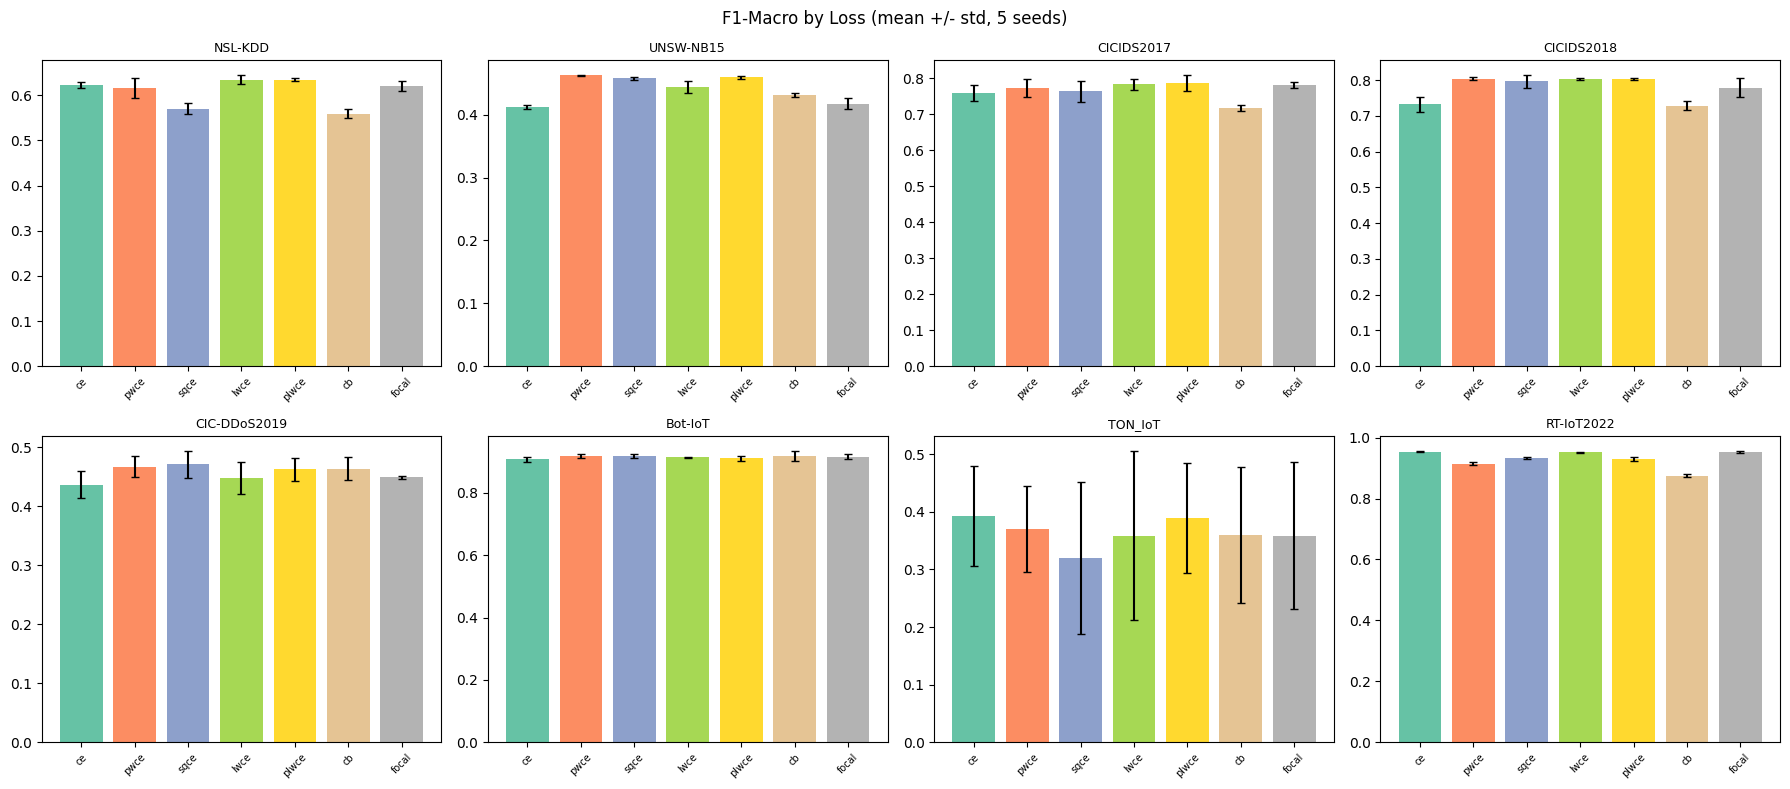

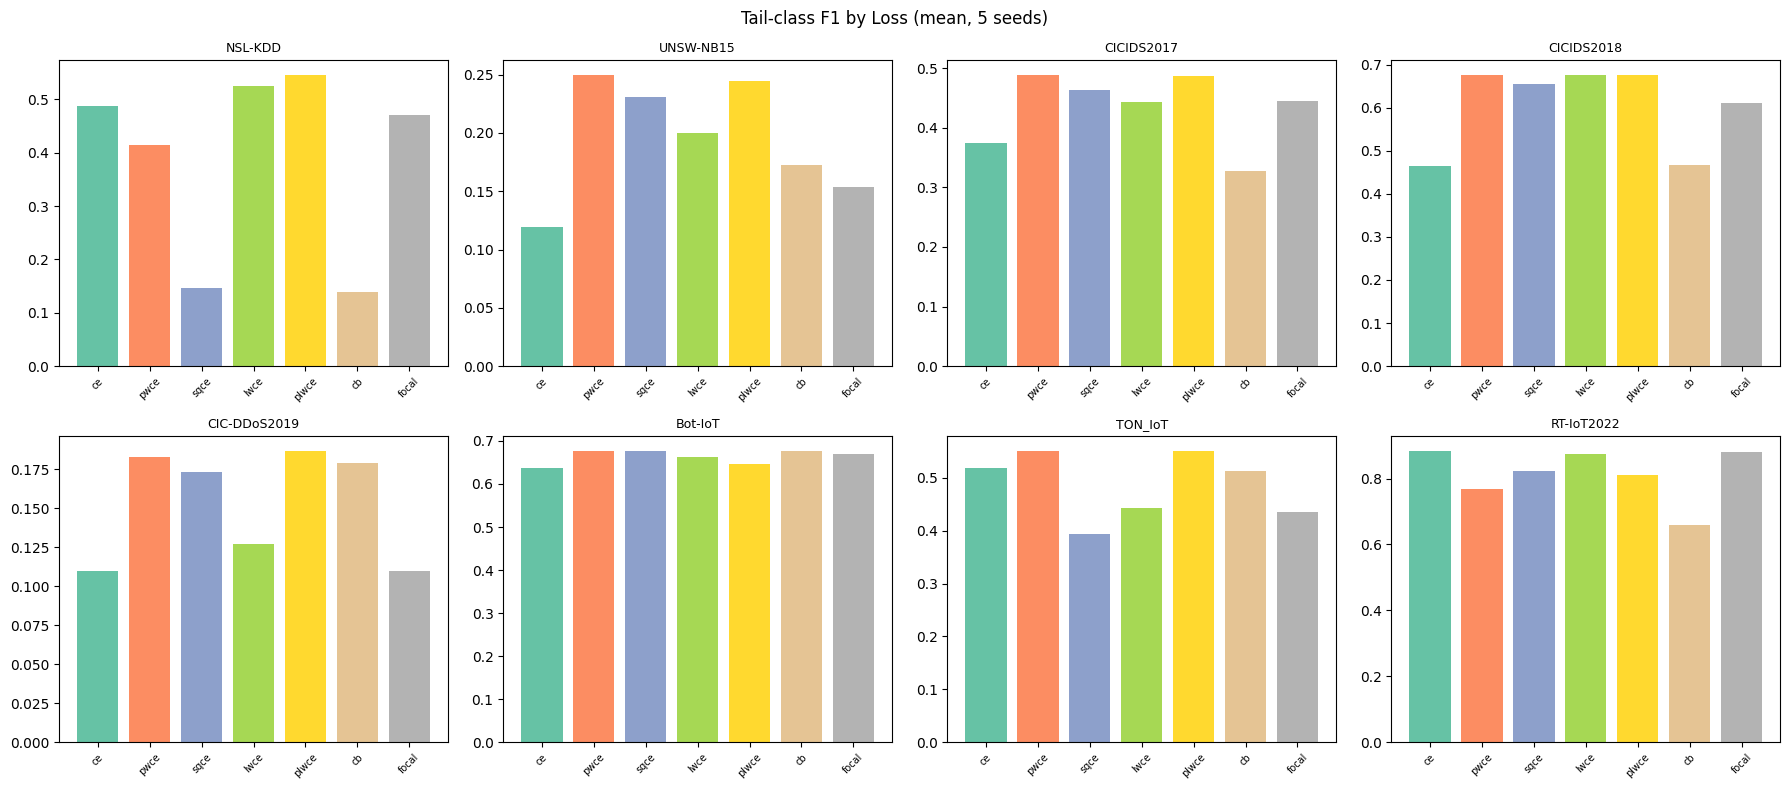

Loss             ce   pwce   sqce   lwce  plwce     cb  focal
Dataset                                                      
Bot-IoT      0.9081 0.9182 0.9182 0.9147 0.9106 0.9179 0.9166
CIC-DDoS2019 0.4365 0.4670 0.4708 0.4471 0.4626 0.4632 0.4486
CICIDS2017   0.7591 0.7729 0.7641 0.7829 0.7866 0.7181 0.7808
CICIDS2018   0.7321 0.8046 0.7965 0.8042 0.8031 0.7291 0.7788
NSL-KDD      0.6232 0.6158 0.5709 0.6349 0.6343 0.5597 0.6209
RT-IoT2022   0.9544 0.9142 0.9328 0.9512 0.9292 0.8752 0.9533
TON_IoT      0.3933 0.3703 0.3203 0.3590 0.3887 0.3604 0.3586
UNSW-NB15    0.4128 0.4624 0.4578 0.4439 0.4594 0.4312 0.4176

Saved: /content/drive/MyDrive/imbalanced-data-LWCE/network_data/results/mlp/network_mlp_results.xlsx
Saved: /content/drive/MyDrive/imbalanced-data-LWCE/network_data/results/mlp/network_mlp_all_results.json


In [6]:
# Cell 5: Aggregate + visualization + save
results_df = pd.DataFrame(all_results)

agg = results_df.groupby(['Dataset', 'Loss']).agg(
    F1_Macro_mean     =('F1_Macro',          'mean'),
    F1_Macro_std      =('F1_Macro',          'std'),
    Balanced_Acc_mean =('Balanced_Accuracy', 'mean'),
    Tail_F1_mean      =('Tail_F1',           'mean'),
    Head_F1_mean      =('Head_F1',           'mean'),
    F1_Weighted_mean  =('F1_Weighted',       'mean'),
).reset_index()

colors  = plt.cm.Set2(np.linspace(0, 1, len(LOSS_CONFIGS)))
ds_list = [d for d in DATASETS if d in set(results_df['Dataset'])]

def grid_plot(value_col, title, fname):
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.flatten()
    for idx, ds in enumerate(ds_list):
        ax  = axes[idx]
        sub = agg[agg['Dataset'] == ds].set_index('Loss')
        means = [sub.loc[l, value_col] if l in sub.index else 0 for l in LOSS_CONFIGS]
        stds  = ([sub.loc[l, 'F1_Macro_std'] if l in sub.index else 0 for l in LOSS_CONFIGS]
                 if value_col == 'F1_Macro_mean' else None)
        ax.bar(LOSS_CONFIGS, means, yerr=stds, color=colors, capsize=3)
        ax.set_title(ds, fontsize=9)
        ax.tick_params(axis='x', rotation=45, labelsize=7)
    for i in range(len(ds_list), len(axes)):
        axes[i].set_visible(False)
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/{fname}', dpi=120, bbox_inches='tight')
    plt.show()

grid_plot('F1_Macro_mean', 'F1-Macro by Loss (mean +/- std, 5 seeds)', 'f1_macro_comparison.png')
grid_plot('Tail_F1_mean',  'Tail-class F1 by Loss (mean, 5 seeds)',    'tail_f1_comparison.png')

pivot = agg.pivot_table(index='Dataset', columns='Loss', values='F1_Macro_mean')
print(pivot[LOSS_CONFIGS].to_string(float_format='{:.4f}'.format))

excel_path = f'{RESULTS_DIR}/network_mlp_results.xlsx'
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    agg.to_excel(writer, sheet_name='Summary', index=False)
    results_df.to_excel(writer, sheet_name='All_Runs', index=False)
    if best_params:
        pd.DataFrame(best_params).T.to_excel(writer, sheet_name='Best_Params')

json.dump(all_results, open(f'{RESULTS_DIR}/network_mlp_all_results.json', 'w'), indent=2)
print(f'\nSaved: {excel_path}')
print(f'Saved: {RESULTS_DIR}/network_mlp_all_results.json')
